# 徐州地区110 kV真实数据完整性与建模可行性审计

## tl;dr

- 主体研究所需的静态资产、21座110 kV站、42台110/10 kV主变、站级光伏容量、110 kV线路限额和8760点光伏标准曲线已经具备。
- 2025年主变小时序列可以作为首版基准，但58列的站/主变映射必须先审批；2026年列顺序不能默认沿用2022-2025年映射。
- 10 kV表没有光伏点位、联络开关、开环点和候选路径，不能开展全局联络优化；该变量按项目硬约束转为后续1-2座站的独立案例。
- 既有方案中的统一50 MVA扩建、合成DC N-1和硬性 `R <= 2.0` 均需调整。推荐采用“站/县基线 + 实际扩建候选 + 参数化容载比成本-可靠性前沿 + 110 kV容量网络N-1”的分层方案。

本 Notebook 只执行数据审计和建模边界判断，不写入正式 `data/raw/`，也不自动批准推断映射。

## Context & Methods

### Key Assumptions

1. 主变小时序列按净负荷解释，现状光伏不得再次扣减。
2. `光伏装机.xlsx` 是站级光伏容量权威来源；10 kV线路“装机容量(kVA)”是下挂配变/用户装见容量。
3. 35 kV只用于解释58条小时序列，不进入110 kV主体容量规划。
4. 所有推断映射、插值、异常修复和单位判断都必须保留状态与置信度。

执行环境必须是 Conda `xuzhou110kv_clr`。审计调用项目内 `_audit_work` 脚本，并将派生结果写到 `results/real_data_audit/`。

In [1]:
from __future__ import annotations

import ast
import hashlib
import json
import os
import re
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT = Path.cwd()
if PROJECT.name == "notebooks":
    PROJECT = PROJECT.parent

DATA_DIR = PROJECT / "data" / "tuomin" / "电网建模数据_Agent整合版_V1.2"
WORK_DIR = PROJECT / "data" / "tuomin" / "_audit_work"
RESULT_DIR = PROJECT / "results" / "real_data_audit"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_DIR.is_dir(), DATA_DIR
assert Path(sys.executable).resolve().as_posix().startswith(
    "/home/xh/anaconda3/envs/xuzhou110kv_clr/"
), sys.executable

print("Python:", sys.executable)
print("Data:", DATA_DIR)

Python: /home/xh/anaconda3/envs/xuzhou110kv_clr/bin/python
Data: /home/xh/postgraduate/干活/徐州电科院项目咨询/徐州地区分布式新能源高渗透率地区110kV电网容载比弹性指标优化研究/实验/研究/data/tuomin/电网建模数据_Agent整合版_V1.2


## Data

### 1. Re-run the source audit

In [2]:
commands = {
    "core_audit.txt": ["xuzhou_core_audit.py"],
    "mapping_2026.txt": ["xuzhou_mapping_2026.py"],
    "hourly_tail_columns.txt": ["xuzhou_tail_columns.py"],
    "monthly_pv.txt": ["xuzhou_monthly_pv_audit.py"],
}

for output_name, args in commands.items():
    completed = subprocess.run(
        [sys.executable, str(WORK_DIR / args[0]), str(DATA_DIR)],
        check=True,
        capture_output=True,
        text=True,
    )
    (RESULT_DIR / output_name).write_text(completed.stdout, encoding="utf-8")

from openpyxl import load_workbook

path = DATA_DIR / "光伏8760小时数据.xlsx"
book = load_workbook(path, read_only=True, data_only=True)
try:
    rows = list(book["光伏8760"].iter_rows(min_row=2, max_row=8761, max_col=6, values_only=True))
finally:
    book.close()
timestamps = pd.to_datetime([row[1] for row in rows])
phi = pd.Series([float(row[4]) for row in rows], index=timestamps)
midnight = phi[phi.index.hour.isin([22, 23, 0, 1, 2, 3, 4])]
midnight_summary = {
    "hours_22_04": len(midnight),
    "positive_count": int((midnight > 0).sum()),
    "max": float(midnight.max()),
    "p99": float(midnight.quantile(0.99)),
    "mean": float(midnight.mean()),
    "positive_energy_hours_equiv": float(midnight.sum()),
}
(RESULT_DIR / "pv_midnight_residual.json").write_text(
    json.dumps(midnight_summary, ensure_ascii=False, indent=2), encoding="utf-8"
)

zip_path = PROJECT / "data" / "tuomin" / "电网建模数据_Agent整合版_V1.2.zip"
archive = {
    "file": zip_path.name,
    "bytes": zip_path.stat().st_size,
    "sha256": hashlib.sha256(zip_path.read_bytes()).hexdigest(),
    "extracted_files": len(list(DATA_DIR.glob("*"))),
}
archive

{'file': '电网建模数据_Agent整合版_V1.2.zip',
 'bytes': 34710343,
 'sha256': 'a8ee4006223b39efdcdc4434c4b315d25ef395a3de1a684e049a70925ab5bec7',
 'extracted_files': 13}

In [3]:
def parse_core_sections(text: str) -> dict[str, object]:
    matches = list(re.finditer(r"^===== ([A-Z0-9_]+) =====$", text, flags=re.MULTILINE))
    sections = {}
    for index, match in enumerate(matches):
        start = match.end()
        end = matches[index + 1].start() if index + 1 < len(matches) else len(text)
        sections[match.group(1)] = json.loads(text[start:end].strip())
    return sections


core = parse_core_sections((RESULT_DIR / "core_audit.txt").read_text(encoding="utf-8"))
assert core["SRC01_STATIONS"]["scope_unique_station_ids"] == 21
assert core["SRC02_TRANSFORMERS"]["scope_110_unique_keys"] == 42
assert core["SRC14_PV_PROFILE"]["row_count"] == 8760
assert core["SRC14_PV_PROFILE"]["non_hourly_gap_count"] == 0

inventory = pd.DataFrame(
    [
        {"数据对象": "110 kV变电站", "数量": 21, "状态": "可直接使用"},
        {"数据对象": "110/10 kV主变", "数量": 42, "状态": "可直接使用"},
        {"数据对象": "研究相关110 kV线路", "数量": 40, "状态": "容量网络可用"},
        {"数据对象": "站级光伏容量覆盖", "数量": 21, "状态": "可直接使用"},
        {"数据对象": "光伏标准曲线小时", "数量": 8760, "状态": "可直接使用"},
        {"数据对象": "研究站下属10 kV馈线", "数量": 342, "状态": "仅筛选/案例准备"},
        {"数据对象": "主变小时序列列", "数量": 58, "状态": "映射审批后使用"},
    ]
)
display(inventory)

,数据对象,数量,状态
0,110 kV变电站,21,可直接使用
1,110/10 kV主变,42,可直接使用
2,研究相关110 kV线路,40,容量网络可用
3,站级光伏容量覆盖,21,可直接使用
4,光伏标准曲线小时,8760,可直接使用
5,研究站下属10 kV馈线,342,仅筛选/案例准备
6,主变小时序列列,58,映射审批后使用


## Results

### 2. Capacity scopes reconcile after separating the new station

,口径,容量_MVA,说明
0,2025历史运行口径,2139.5,20座成熟站
1,SRC01站级汇总,2221.0,BDZ-00005少18.5 MVA
2,SRC02/SRC03年末设备,2239.5,21座站，含BDZ-00056


/tmp/ipykernel_40927/3011226070.py:17: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/3011226070.py:17: UserWarning: Glyph 21464 (\N{CJK UNIFIED IDEOGRAPH-53D8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/3011226070.py:17: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/3011226070.py:17: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/3011226070.py:17: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/3011226070.py:17: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/3011226070.py:17: UserWarning: Glyph 36816 (\N{CJK UNIFIED IDEOGRAP

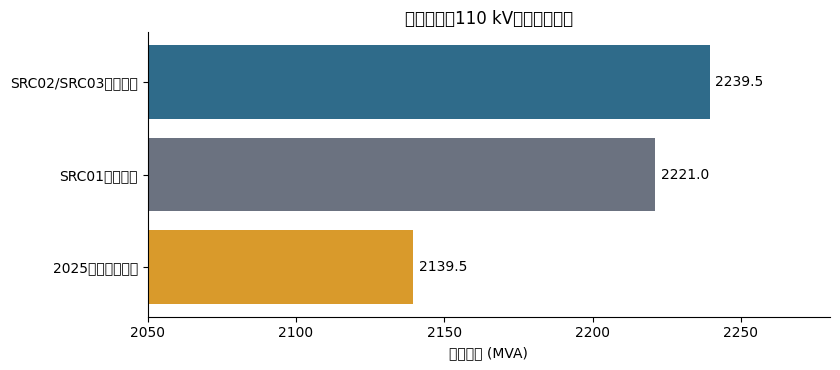

In [4]:
capacity = pd.DataFrame(
    [
        {"口径": "2025历史运行口径", "容量_MVA": 2139.5, "说明": "20座成熟站"},
        {"口径": "SRC01站级汇总", "容量_MVA": 2221.0, "说明": "BDZ-00005少18.5 MVA"},
        {"口径": "SRC02/SRC03年末设备", "容量_MVA": 2239.5, "说明": "21座站，含BDZ-00056"},
    ]
)
display(capacity)

fig, ax = plt.subplots(figsize=(8.5, 3.8))
bars = ax.barh(capacity["口径"], capacity["容量_MVA"], color=["#D99A2B", "#6B7280", "#2F6B8A"])
ax.set_xlim(2050, 2280)
ax.set_xlabel("主变容量 (MVA)")
ax.set_title("不同源表的110 kV主变容量口径")
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

assert abs(2239.5 - 100.0 - 2139.5) < 1e-9

SRC02/SRC03的单台设备容量总计为2239.5 MVA。剔除2025年底新投运、负荷尚未完全释放的 `BDZ-00056`（100 MVA）后，正好得到历史容载比表2025年的2139.5 MVA。SRC01的2221.0 MVA则另外包含 `BDZ-00005` 的18.5 MVA汇总差异。首版模型应区分“2025校准范围”和“年末/当前资产范围”，容量以单台设备表为准。

### 3. Static and network inputs are sufficient, but expansion must be station-specific

/tmp/ipykernel_40927/2475844149.py:18: UserWarning: Glyph 38745 (\N{CJK UNIFIED IDEOGRAPH-9759}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/2475844149.py:18: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/2475844149.py:18: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/2475844149.py:18: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/2475844149.py:18: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/2475844149.py:18: UserWarning: Glyph 36733 (\N{CJK UNIFIED IDEOGRAPH-8F7D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/2475844149.py:18: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAP

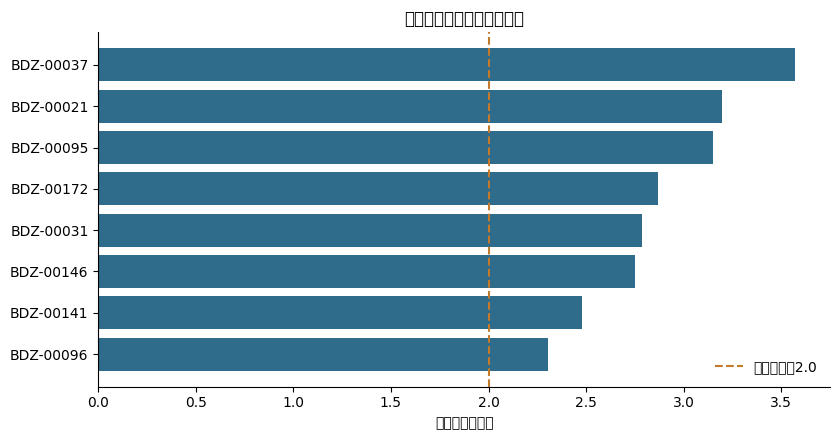

,检查项,结果,结论
0,可扩建站,14.0,使用源表离散候选
1,可扩建容量,793.0,不可统一假设2x50 MVA
2,剩余10 kV间隔,131.0,6座站无剩余间隔
3,研究相关线路,40.0,容量网络/N-1可用
4,边界节点,8.0,2个节点身份待确认


In [5]:
station_detail = pd.DataFrame(core["KEY_STATION_DETAIL"])
station_detail.to_csv(RESULT_DIR / "station_detail.csv", index=False)

top_clr = station_detail.dropna(subset=["static_bidirectional_clr"]).nlargest(
    8, "static_bidirectional_clr"
)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bars = ax.barh(
    top_clr["station_id"][::-1],
    top_clr["static_bidirectional_clr"][::-1],
    color="#2F6B8A",
)
ax.axvline(2.0, color="#C47A2C", linestyle="--", linewidth=1.5, label="旧方案上限2.0")
ax.set_xlabel("静态双向容载比")
ax.set_title("静态双向容载比较高的站点")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

equipment = core["SRC03_EQUIPMENT"]
network = core["SRC04_NETWORK"]
pd.DataFrame(
    [
        {"检查项": "可扩建站", "结果": equipment["expandable_station_count"], "结论": "使用源表离散候选"},
        {"检查项": "可扩建容量", "结果": equipment["expandable_capacity_sum_mva"], "结论": "不可统一假设2x50 MVA"},
        {"检查项": "剩余10 kV间隔", "结果": equipment["remaining_10kv_bays_sum"], "结论": "6座站无剩余间隔"},
        {"检查项": "研究相关线路", "结果": network["unique_touching_line_ids"], "结论": "容量网络/N-1可用"},
        {"检查项": "边界节点", "结果": network["boundary_node_count"], "结论": "2个节点身份待确认"},
    ]
)

站级静态容载比使用的是各站年度极值，只能用于筛选，不能将各站非同时峰值求和替代县域同步峰值。旧方案把2.0设为全局硬上限会与2025年官方县域容载比2.24及部分既有高容载比站冲突；在没有退役变量时，还可能诱导储能人为抬高峰值以降低比值。2.0应转为对标线或参数扫描点，而不是直接约束既有资产。

### 4. Hourly data are usable after mapping approval and explicit repairs

In [6]:
hourly = core["SRC07_HOURLY"]
hourly_quality = pd.DataFrame(
    [
        {
            "工作表": sheet,
            "年份": ", ".join(map(str, info["year_counts"].keys())),
            "小时数": info["row_count"],
            "有效列": info["active_column_count"],
            "全列空白小时": info["all_series_missing_row_count"],
            "最小值": info["min_value"],
            "最大值": info["max_value"],
        }
        for sheet, info in hourly.items()
    ]
)
hourly_quality.to_csv(RESULT_DIR / "hourly_quality.csv", index=False)
display(hourly_quality)

mapping = core["SRC07_MAPPING_DIAGNOSTIC"]
mapping_2026_line = (RESULT_DIR / "mapping_2026.txt").read_text(encoding="utf-8").splitlines()[0]
mapping_2026 = ast.literal_eval(mapping_2026_line.removeprefix("summary "))
mapping_confidence = pd.DataFrame(
    [
        {"诊断": "2025匹配分数<0.10", "列数": mapping["assigned_score_below_0_10"], "总列数": 58},
        {"诊断": "2025匹配分数<0.25", "列数": mapping["assigned_score_below_0_25"], "总列数": 58},
        {"诊断": "2025匹配分数<0.50", "列数": mapping["assigned_score_below_0_50"], "总列数": 58},
        {"诊断": "2026快照误差<=0.5 MW", "列数": mapping_2026["error_le_0_5_mw"], "总列数": 58},
        {"诊断": "2026快照误差<=2 MW", "列数": mapping_2026["error_le_2_mw"], "总列数": 58},
    ]
)
display(mapping_confidence)

pd.DataFrame(mapping["assignments"]).to_csv(
    RESULT_DIR / "timeseries_column_map_2025_candidate.csv", index=False
)

,工作表,年份,小时数,有效列,全列空白小时,最小值,最大值
0,Sheet1,2022,8760,54,1,-10.14,52.37
1,Sheet2,2023,8760,54,2,-8.74,60.88
2,Sheet3,"2024, 2025",17544,58,3,-7319.00,16630.00
3,Sheet4,2026,4992,58,1,-55.46,56.03


,诊断,列数,总列数
0,2025匹配分数<0.10,37,58
1,2025匹配分数<0.25,51,58
2,2025匹配分数<0.50,56,58
3,2026快照误差<=0.5 MW,32,58
4,2026快照误差<=2 MW,54,58


每年3月的整行空白恰好对应美国夏令时跳时日期，而中国没有该跳时，属于可重复的时区/ETL伪影；另有少量随机整行缺失。Sheet3还存在3个数量级异常值（-7319、-6858、16630），应先隔离并按邻域规则修复，同时保留 `quality_flag`。源表首行58个站码全部损坏为同一编号，第二行仅26列保留主变号，因此候选映射不能自动转正。

2025年基于年度极值和极值时刻的候选匹配中，51/58列分数低于0.25，足以支撑人工审批；但2026快照诊断表明列顺序已经变化，正式映射至少要拆为 `2022_2025` 与 `2026` 两版。首版主体模型只使用2025年，可先审批2025映射，2026留作后续验证。

### 5. PV data remove the need for random station placement

,口径,容量_MW
0,已并网,1460.9273
1,在途,260.4057
2,已并网+在途,1721.3330


,row_count,timestamp_unique_count,timestamp_missing_count,start,end,non_hourly_gap_count,phi_missing_count,phi_min,phi_max,phi_mean,equivalent_full_load_hours,out_of_range_count,scaled_3408_max_abs_error_mw,night_hours,night_positive_count,night_phi_max,exact_zero_count,midnight_22_04_max
0,8760,8760,0,2025-01-01 00:00:00,2025-12-31 23:00:00,0,0,0.0,0.99585,0.148071,1297.1,0,0.0,3650,3213,0.077868,739,0.004326


/tmp/ipykernel_40927/1764428646.py:19: UserWarning: Glyph 24050 (\N{CJK UNIFIED IDEOGRAPH-5DF2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/1764428646.py:19: UserWarning: Glyph 24182 (\N{CJK UNIFIED IDEOGRAPH-5E76}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/1764428646.py:19: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/1764428646.py:19: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/1764428646.py:19: UserWarning: Glyph 36884 (\N{CJK UNIFIED IDEOGRAPH-9014}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/1764428646.py:19: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_40927/1764428646.py:19: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAP

/home/xh/anaconda3/envs/xuzhou110kv_clr/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xh/anaconda3/envs/xuzhou110kv_clr/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xh/anaconda3/envs/xuzhou110kv_clr/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31449 (\N{CJK UNIFIED IDEOGRAPH-7AD9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xh/anaconda3/envs/xuzhou110kv_clr/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32423 (\N{CJK UNIFIED IDEOGRAPH-7EA7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/xh/anaconda3/envs/xuzhou110kv_clr/lib/python3.13/site-

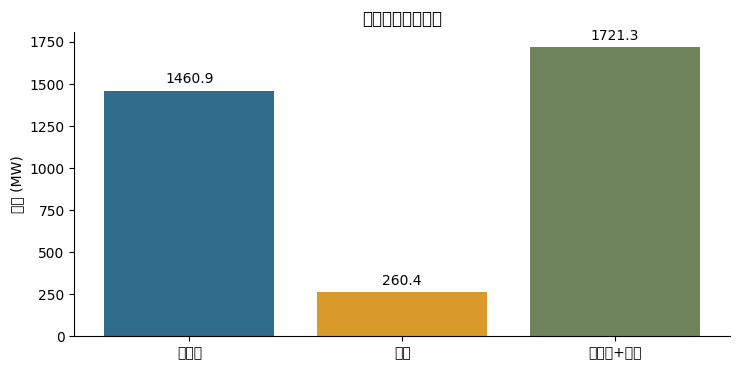

In [7]:
pv = core["SRC05_PV_CAPACITY"]
profile = core["SRC14_PV_PROFILE"]
pv_summary = pd.DataFrame(
    [
        {"口径": "已并网", "容量_MW": pv["online_total_mw"]},
        {"口径": "在途", "容量_MW": pv["pipeline_total_mw"]},
        {"口径": "已并网+在途", "容量_MW": pv["online_plus_pipeline_total_mw"]},
    ]
)
display(pv_summary)
display(pd.DataFrame([profile | {"midnight_22_04_max": midnight_summary["max"]}]))

fig, ax = plt.subplots(figsize=(7.5, 3.8))
bars = ax.bar(pv_summary["口径"], pv_summary["容量_MW"], color=["#2F6B8A", "#D99A2B", "#70845B"])
ax.set_ylabel("容量 (MW)")
ax.set_title("站级光伏容量快照")
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

21座站均有站级光伏容量，不需要在110 kV站间“随机撒点”。未知的是光伏在10 kV馈线内的具体接入点，因此不能把站级容量随机分摊后当作真实拓扑；如需评估该不确定性，只能作为带标签的敏感性场景。统一8760曲线完整、范围合法，等效利用小时约1297.1 h；22:00-04:00仍有最大0.00433 p.u.的微小非零值，默认保留原始曲线，清洗版只能作为敏感性分支。

### 6. Modeling readiness and mandatory boundaries

In [8]:
readiness = pd.DataFrame(
    [
        {"层级": "M0 站级静态筛选", "状态": "可直接开展", "首版处理": "21站；2025口径单列"},
        {"层级": "M1 扩建候选", "状态": "可直接构造", "首版处理": "使用SRC03站级离散候选和间隔"},
        {"层级": "M2 小时储能/弃光", "状态": "条件具备", "首版处理": "审批2025映射；补储能参数"},
        {"层级": "M3 110 kV N-1", "状态": "容量网络可做", "首版处理": "电流限额换算；不声称AC/DC潮流"},
        {"层级": "M4 县域对标", "状态": "可直接开展", "首版处理": "月度PV单位标记为待确认"},
        {"层级": "M5 10 kV联络", "状态": "主体禁用", "首版处理": "后续1-2站独立案例"},
    ]
)
readiness.to_csv(RESULT_DIR / "model_readiness.csv", index=False)
display(readiness)

,层级,状态,首版处理
0,M0 站级静态筛选,可直接开展,21站；2025口径单列
1,M1 扩建候选,可直接构造,使用SRC03站级离散候选和间隔
2,M2 小时储能/弃光,条件具备,审批2025映射；补储能参数
3,M3 110 kV N-1,容量网络可做,电流限额换算；不声称AC/DC潮流
4,M4 县域对标,可直接开展,月度PV单位标记为待确认
5,M5 10 kV联络,主体禁用,后续1-2站独立案例


## Takeaways

### Recommended modeling route

1. **数据层**：建立真实数据适配与质量标记，先产出2025年站级净负荷；不改写源文件，不重复扣减现状PV。
2. **基线层**：分别给出2025运行口径（20座成熟站、2139.5 MVA）和年末资产口径（21座、2239.5 MVA），县域、站级结果不混用非同时峰值。
3. **规划层**：采用源表离散扩建候选，叠加储能、弃光与新增PV场景；未来净负荷只扣减新增PV。负荷增长应优先用夜间/晚峰估计或设区间，避免直接放大已含PV的净负荷。
4. **指标层**：将旧A/B方案降为对照，主体采用容载比目标参数扫描，输出成本、可靠性、弃光率和N-1可行性的前沿及推荐区间。未封顶成本最优解的结果容载比只能是描述值，不能直接叫“推荐值”。
5. **网络层**：使用110 kV电流限额构建容量网络和拓扑N-1；在缺R/X时不补造精确DC/AC潮流。
6. **案例层**：10 kV联络优化从全局变量移除，待1-2座站的开关、开环点、候选联络路径和馈线级PV映射到位后，单独测算优化前后成本。

### Before the formal run

- 审批 `timeseries_column_map_2022_2025`，并单列2026映射。
- 确认月度分县光伏单位；当前仅可标记为“推断为万kW”。
- 确认两个外部边界节点 `BDZ-00336`、`BDZ-00362` 的类型。
- 补齐储能CAPEX/OPEX、效率、SOC、寿命、退化和折现参数。
- 如继续输出高压分区结果，补充站-220 kV电源的运行分区/开关状态；否则首版只做站级与县域。

In [9]:
summary = {
    "archive": archive,
    "scope": {
        "stations_110kv": 21,
        "transformers_110kv": 42,
        "transformers_35kv_context": 16,
        "network_lines_touching_scope": 40,
        "feeders_in_scope": 342,
    },
    "capacity_mva": {
        "historical_2025": 2139.5,
        "station_src01": 2221.0,
        "unit_year_end": 2239.5,
    },
    "pv": {
        "online_mw": pv["online_total_mw"],
        "pipeline_mw": pv["pipeline_total_mw"],
        "profile_hours": profile["row_count"],
        "equivalent_full_load_hours": profile["equivalent_full_load_hours"],
    },
    "mapping": {
        "2025_score_below_0_25": mapping["assigned_score_below_0_25"],
        "2026_snapshot_error_le_0_5_mw": mapping_2026["error_le_0_5_mw"],
        "approval_status": "candidate_only",
    },
    "decision": "layered_redesign_recommended",
}
(RESULT_DIR / "audit_summary.json").write_text(
    json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8"
)
summary

{'archive': {'file': '电网建模数据_Agent整合版_V1.2.zip',
  'bytes': 34710343,
  'sha256': 'a8ee4006223b39efdcdc4434c4b315d25ef395a3de1a684e049a70925ab5bec7',
  'extracted_files': 13},
 'scope': {'stations_110kv': 21,
  'transformers_110kv': 42,
  'transformers_35kv_context': 16,
  'network_lines_touching_scope': 40,
  'feeders_in_scope': 342},
 'capacity_mva': {'historical_2025': 2139.5,
  'station_src01': 2221.0,
  'unit_year_end': 2239.5},
 'pv': {'online_mw': 1460.9273,
  'pipeline_mw': 260.4057,
  'profile_hours': 8760,
  'equivalent_full_load_hours': 1297.1},
 'mapping': {'2025_score_below_0_25': 51,
  '2026_snapshot_error_le_0_5_mw': 32,
  'approval_status': 'candidate_only'},
 'decision': 'layered_redesign_recommended'}